<a href="https://colab.research.google.com/github/Megh-05/Data-Science/blob/main/Exp_No_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 246s 1us/step


/tmp/ipykernel_2528/3025979396.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(labels[int(train_y[img])])


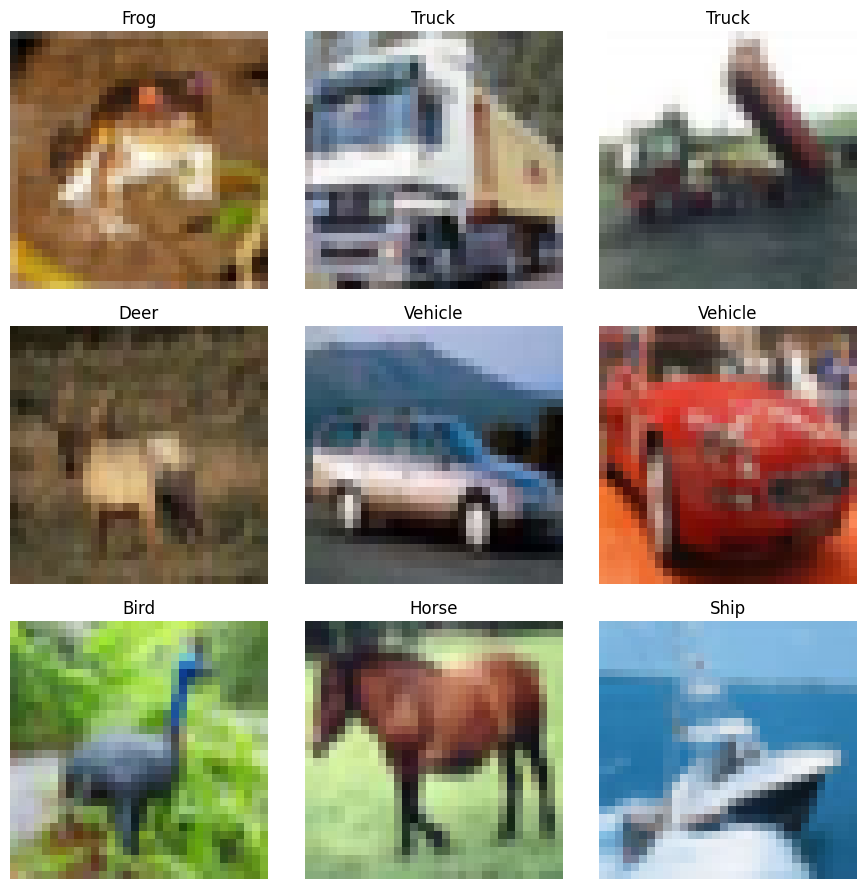

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,602 (2.51 MB)

 Trainable params: 658,410 (2.51 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 217s 152ms/step - accuracy: 0.4367 - loss: 1.5692 - val_accuracy: 0.5254 - val_loss: 1.3100
Epoch 2/12
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 222s 158ms/step - accuracy: 0.5892 - loss: 1.1684 - val_accuracy: 0.6710 - val_loss: 0.9562
Epoch 3/12
 687/1407 ━━━━━━━━━━━━━━━━━━━━ 1:50 153ms/step - accuracy: 0.6348 - loss: 1.0521

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

# Load CIFAR-10 Data

(train_x, train_y), (test_x, test_y) = cifar10.load_data()

# Normalize Image Data

train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0

# Category Labels

labels = [
    "Plane",
    "Vehicle",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Display Training Images

plt.figure(figsize=(9, 9))

for img in range(9):

    plt.subplot(3, 3, img + 1)

    plt.imshow(train_x[img])

    plt.title(labels[int(train_y[img])])

    plt.axis("off")

plt.tight_layout()
plt.show()

# CNN Network

cnn_network = Sequential()

# Convolution Layer Block 1

cnn_network.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    )
)

cnn_network.add(BatchNormalization())

cnn_network.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    )
)

cnn_network.add(MaxPool2D(pool_size=(2, 2)))

cnn_network.add(Dropout(0.2))

# Convolution Layer Block 2

cnn_network.add(
    Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    )
)

cnn_network.add(BatchNormalization())

cnn_network.add(
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

cnn_network.add(MaxPool2D(pool_size=(2, 2)))

cnn_network.add(Dropout(0.3))

# Flatten Output

cnn_network.add(Flatten())

# Dense Neural Layers

cnn_network.add(
    Dense(
        256,
        activation='relu'
    )
)

cnn_network.add(Dropout(0.4))

cnn_network.add(
    Dense(
        10,
        activation='softmax'
    )
)

# Display Model Details

cnn_network.summary()

# Compile Deep Learning Model

cnn_network.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the CNN

cnn_history = cnn_network.fit(
    train_x,
    train_y,
    epochs=12,
    batch_size=32,
    validation_split=0.1
)

# Evaluate Performance

final_loss, final_accuracy = cnn_network.evaluate(
    test_x,
    test_y
)

print("\nModel Test Accuracy :", final_accuracy)

# Accuracy Visualization

plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)

plt.show()

# Loss Visualization

plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.show()